In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

In [20]:
# set seeds for reproducipiity
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Import Data 

In [21]:
Test_Data_PINN=pd.read_csv('Test_Data_PINN.csv').dropna(how='all').dropna(axis=1, how='all')
Traning_Data_PINN=pd.read_csv('Traning_Data_PINN.csv').dropna(how='all').dropna(axis=1, how='all')

In [22]:
Test_Data_PINN

,launching velocity,launching angel,initial height,horizontal Distance,vertical Distance
0,6.051233,0.513825,1.138398,-0.006974,1.138398
1,6.051233,0.513825,1.138398,0.166728,1.239402
2,6.051233,0.513825,1.138398,0.344086,1.336601
3,6.051233,0.513825,1.138398,0.524724,1.411342
4,6.051233,0.513825,1.138398,0.720284,1.485783
...,...,...,...,...,...
66,5.690068,0.455694,0.996565,3.031141,0.826734
67,5.690068,0.455694,0.996565,3.193667,0.697057
68,5.690068,0.455694,0.996565,3.351415,0.572180
69,5.690068,0.455694,0.996565,3.509109,0.423358


In [23]:
Traning_Data_PINN

,launching velocity,launching angel,initial height,horizontal Distance,vertical Distance
0,6.136734,0.544478,1.04499,-0.002680,1.04499
1,6.136734,0.544478,1.04499,0.170120,1.14886
2,6.136734,0.544478,1.04499,0.347050,1.25676
3,6.136734,0.544478,1.04499,0.519790,1.35655
4,6.136734,0.544478,1.04499,0.692210,1.43185
...,...,...,...,...,...
130,6.505587,0.290258,0.94330,2.931266,0.88654
131,6.505587,0.290258,0.94330,3.101047,0.79115
132,6.505587,0.290258,0.94330,3.285793,0.68072
133,6.505587,0.290258,0.94330,3.475504,0.55528


In [24]:
Test_Data_PINN.columns

Index(['launching velocity', 'launching angel', 'initial height',
       ' horizontal Distance ', 'vertical Distance'],
      dtype='object')

In [25]:
Traning_Data_PINN.columns

Index(['launching velocity', 'launching angel', 'initial height',
       ' horizontal Distance ', 'vertical Distance'],
      dtype='object')

In [26]:
Test_Data_PINN.head()

,launching velocity,launching angel,initial height,horizontal Distance,vertical Distance
0,6.051233,0.513825,1.138398,-0.006974,1.138398
1,6.051233,0.513825,1.138398,0.166728,1.239402
2,6.051233,0.513825,1.138398,0.344086,1.336601
3,6.051233,0.513825,1.138398,0.524724,1.411342
4,6.051233,0.513825,1.138398,0.720284,1.485783


In [27]:
Traning_Data_PINN.head()

,launching velocity,launching angel,initial height,horizontal Distance,vertical Distance
0,6.136734,0.544478,1.04499,-0.00268,1.04499
1,6.136734,0.544478,1.04499,0.17012,1.14886
2,6.136734,0.544478,1.04499,0.34705,1.25676
3,6.136734,0.544478,1.04499,0.51979,1.35655
4,6.136734,0.544478,1.04499,0.69221,1.43185


In [28]:
Input = ['launching velocity', 'launching angel', 'initial height',
       ' horizontal Distance ']
Output = ['vertical Distance']

# Data for Training and Testing 

In [29]:
Test_Data_PINN_Input  = Test_Data_PINN[Input]
Test_Data_PINN_Output = Test_Data_PINN[Output]

Traning_Data_PINN_Input  = Traning_Data_PINN[Input]
Traning_Data_PINN_Output = Traning_Data_PINN[Output]


In [30]:
Test_Data_PINN_Input.head()

,launching velocity,launching angel,initial height,horizontal Distance
0,6.051233,0.513825,1.138398,-0.006974
1,6.051233,0.513825,1.138398,0.166728
2,6.051233,0.513825,1.138398,0.344086
3,6.051233,0.513825,1.138398,0.524724
4,6.051233,0.513825,1.138398,0.720284


In [31]:
Test_Data_PINN_Output.head()

,vertical Distance
0,1.138398
1,1.239402
2,1.336601
3,1.411342
4,1.485783


In [32]:
Traning_Data_PINN_Input.head()

,launching velocity,launching angel,initial height,horizontal Distance
0,6.136734,0.544478,1.04499,-0.00268
1,6.136734,0.544478,1.04499,0.17012
2,6.136734,0.544478,1.04499,0.34705
3,6.136734,0.544478,1.04499,0.51979
4,6.136734,0.544478,1.04499,0.69221


In [33]:
Traning_Data_PINN_Output.head()

,vertical Distance
0,1.04499
1,1.14886
2,1.25676
3,1.35655
4,1.43185


# Visualize the data

In [34]:
unique_sets_Traning = Traning_Data_PINN['launching velocity'].unique()
unique_sets_Test = Test_Data_PINN['launching velocity'].unique()


### Training set

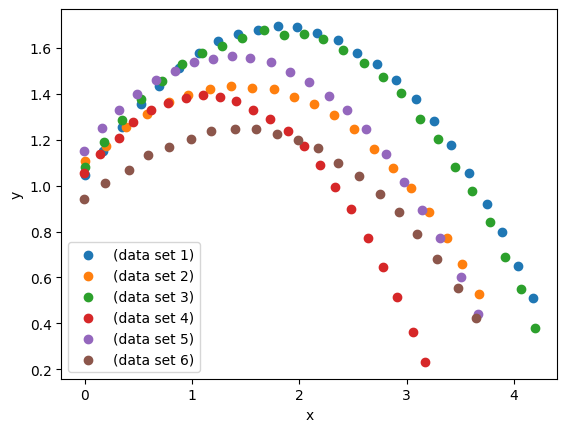

In [35]:
k=1
for i in unique_sets_Traning :
     filtered_data_Traning_Data_PINN = Traning_Data_PINN[Traning_Data_PINN['launching velocity'] == i]
     x=filtered_data_Traning_Data_PINN[' horizontal Distance ']
     y=filtered_data_Traning_Data_PINN['vertical Distance']
     plt.scatter(x,y, label=f'(data set {k})')
     k+=1
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Test set

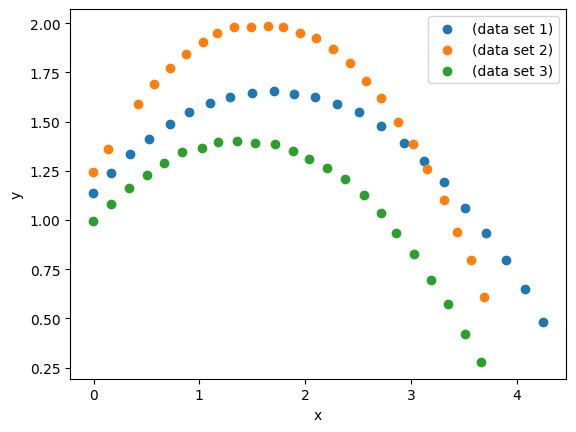

In [36]:
k=1
for i in unique_sets_Test :
     filtered_data_Test_Data_PINN = Test_Data_PINN[Test_Data_PINN['launching velocity'] == i]
     x=filtered_data_Test_Data_PINN[' horizontal Distance ']
     y=filtered_data_Test_Data_PINN['vertical Distance']
     plt.scatter(x,y, label=f'(data set {k})')
     k+=1 
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Build The NN Model

## Put the Data in Tensor form 

In [37]:
Test_Data_PINN_Input  = Test_Data_PINN[Input]
Test_Data_PINN_Output = Test_Data_PINN[Output]

Traning_Data_PINN_Input  = Traning_Data_PINN[Input]
Traning_Data_PINN_Output = Traning_Data_PINN[Output]

x_train = tf.convert_to_tensor(Traning_Data_PINN_Input  , dtype=tf.float32)
y_train = tf.convert_to_tensor(Traning_Data_PINN_Output , dtype=tf.float32)  
x_test  = tf.convert_to_tensor(Test_Data_PINN_Input     , dtype=tf.float32)
y_test  = tf.convert_to_tensor(Test_Data_PINN_Output    , dtype=tf.float32)

batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

## Draw The PINN Archeitcture 

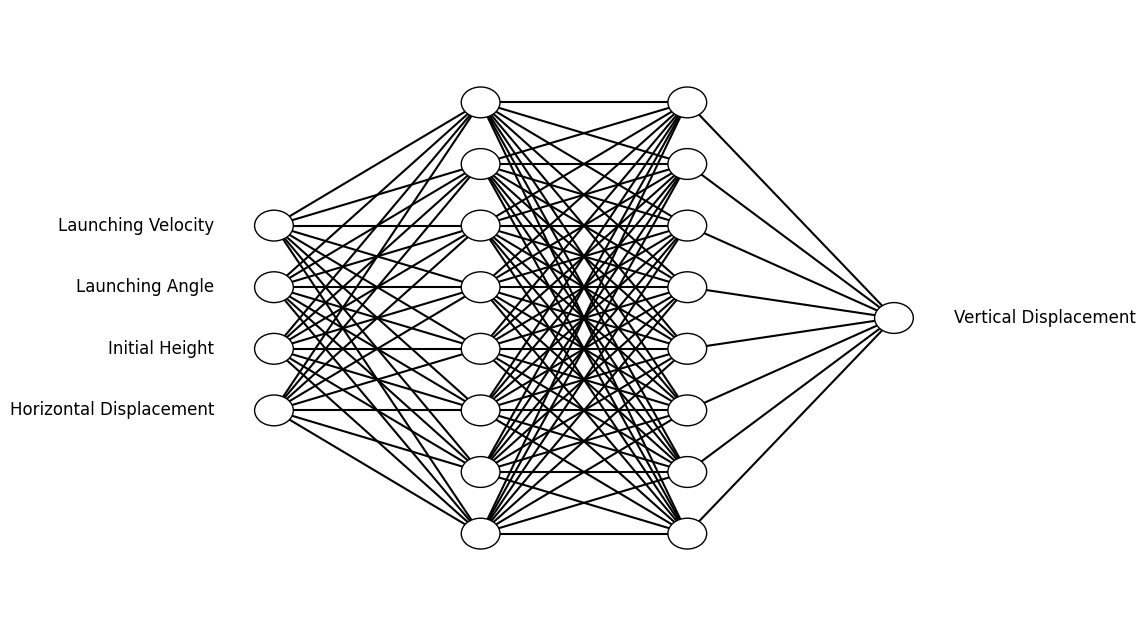

<Figure size 640x480 with 0 Axes>

In [38]:
def draw_neural_net_with_labels(ax, left, right, bottom, top, layer_sizes, input_labels=None, output_label=None):
    '''
    Draw a neural network cartoon using matplotlib with labeled input and output neurons.
    
    :param ax: matplotlib.axes.AxesSubplot, the axes on which to plot the cartoon (get e.g. by plt.gca())
    :param left: float, the center of the leftmost node(s) will be placed here
    :param right: float, the center of the rightmost node(s) will be placed here
    :param bottom: float, the center of the bottommost node(s) will be placed here
    :param top: float, the center of the topmost node(s) will be placed here
    :param layer_sizes: list of int, list containing the number of nodes in each layer
    :param input_labels: list of str, labels for the input neurons
    :param output_label: str, label for the output neuron
    '''
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(len(layer_sizes) - 1)

    # Nodes
    for i, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2. + (top + bottom) / 2.
        for j in range(layer_size):
            circle = plt.Circle((i * h_spacing + left, layer_top - j * v_spacing), v_spacing / 4.,
                                color='w', ec='k', zorder=4)
            ax.add_artist(circle)

            # Add labels to input and output neurons
            if i == 0 and input_labels is not None:  # Input layer
                ax.annotate(input_labels[j], (i * h_spacing + left - 0.05, layer_top - j * v_spacing),
                            xytext=(-15, 0), textcoords='offset points', ha='right', va='center', fontsize=12)
            elif i == len(layer_sizes) - 1 and output_label is not None:  # Output layer
                ax.annotate(output_label, (i * h_spacing + left + 0.05, layer_top - j * v_spacing),
                            xytext=(15, 0), textcoords='offset points', ha='left', va='center', fontsize=12)

    # Edges
    for i, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2. + (top + bottom) / 2.
        layer_top_b = v_spacing * (layer_size_b - 1) / 2. + (top + bottom) / 2.
        for j in range(layer_size_a):
            for k in range(layer_size_b):
                line = plt.Line2D([i * h_spacing + left, (i + 1) * h_spacing + left],
                                  [layer_top_a - j * v_spacing, layer_top_b - k * v_spacing], c='k')
                ax.add_artist(line)

# Define the architecture and labels
layer_sizes = [4, 8, 8, 1]
input_labels = ['Launching Velocity', 'Launching Angle', 'Initial Height', 'Horizontal Displacement']
output_label = 'Vertical Displacement'

fig = plt.figure(figsize=(10, 8))
ax = fig.gca()
ax.axis('off')
draw_neural_net_with_labels(ax, .1, .9, .1, .9, layer_sizes, input_labels=input_labels, output_label=output_label)
plt.show()
#plt.savefig('PINN Archeitcture.jpg')


## Study the NN model : Evaluate the Required Epochs

 Following page 311 Book PATTERN  CLASSIFICATION by Richard 0. Duda  Peter E.  Hart  David G. Stork 
Number of all coeffient in system ~ n/10 ~ 134/10 so as it very small, using the concept that n_coefecient < data 

This step will be excuted for ten times to average the epoch for minimum test as recommedde by Richard 0. Duda, page 295 fig 6.6

In [52]:
import time
# Start timer
start_time = time.time()

from tensorflow import keras
from keras.layers import Dense , Input as Input_NN
from keras.callbacks import Callback

all_epoches=[]
Traning_Error_all=[]
Test_Error_all=[]

n_of_trials=11 # increase by 1 as range exclude last one
n=n_of_trials
num_epochs=6000


for i in range (1,n):
                def loss(model, x, y):
                      y_ = model(x)
                      mse_data= tf.reduce_mean(tf.square( y_ - y))
                      p_f=  x[:,2] +  x[:,3]*tf.tan(x[:,1])-9.81*tf.square(x[:,3])/( 2*tf.square(x[:,0])*tf.square(tf.cos(x[:,1])) )
                      P_f=tf.reshape(p_f, (p_f.shape[0], 1))
                      physics_loss = tf.reduce_mean(tf.square(y_ - P_f))
                      return   physics_loss + mse_data

                def grad(model, inputs, targets):
                    with tf.GradientTape() as tape:
                         loss_value = loss(model, inputs, targets)
                    return loss_value, tape.gradient(loss_value, model.trainable_variables)
                optimizer = tf.keras.optimizers.Adam()
                Test_Error=[]

############## MODEL #####################
                models = keras.models
                model = models.Sequential()
                # input layer
                model.add(Input_NN(shape=(4,))) 
                # Hidden layer
                model.add(Dense(8, activation='softplus') ) # 1
                model.add(Dense(8, activation='softplus') ) # 2
                # Output layer
                model.add(Dense(1, activation='softplus') )
############# MODEL #####################

                for epoch in range(num_epochs):
                    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
                            x=x_batch_train
                            y=y_batch_train
                            epoch_loss_avg = tf.keras.metrics.Mean()
                            epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
                            
                            # Training loop - using batches of 32
                            # Optimize the model
                            loss_value, grads = grad(model, x , y )
                            optimizer.apply_gradients(zip(grads, model.trainable_variables))
                            
                            # Track progress
                            epoch_loss_avg.update_state(loss_value)  # Add current batch loss
                            epoch_accuracy.update_state(y, model(x))
                    y_model_test=model(x_test)
                    y_model_train=model(x_train)
                    Test_Error.append(tf.reduce_mean(tf.square(y_model_test - y_test)))
                    Traning_Error_all.append(tf.reduce_mean(tf.square(y_model_train - y_train)))
                    Test_Error_all.append(tf.reduce_mean(tf.square(y_model_test - y_test)))
    
                epoches=tf.argmin(Test_Error)
                all_epoches.append(epoches)
# End timer
end_time = time.time()
# Calculate elapsed time
elapsed_time = end_time - start_time
print("Elapsed time: ", elapsed_time)

Elapsed time:  17506.912321805954


### Error Analysis

#### All Runs 

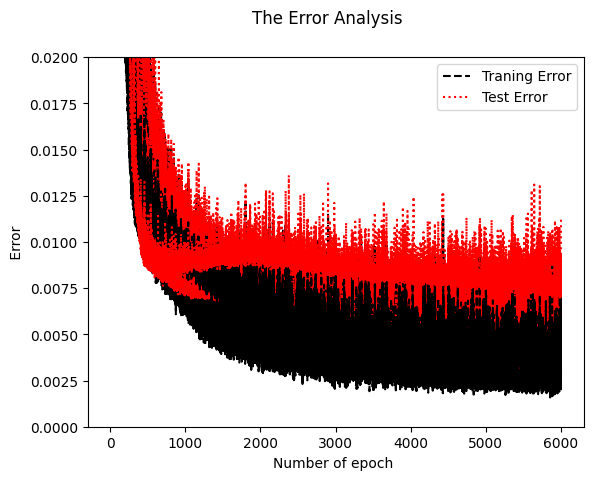

optimum epochs  5363.9


In [54]:
f, ax = plt.subplots(1)
for i in range(1,n): 
    if i == n-1 :
        ax.plot([*range(0, num_epochs, 1)], Traning_Error_all[(i-1)*num_epochs:i*num_epochs]     ,'k',linestyle = 'dashed' , label = 'Traning Error')
        ax.plot( [*range(0, num_epochs, 1)], Test_Error_all[(i-1)*num_epochs:i*num_epochs]       , 'r',linestyle = 'dotted',  label = 'Test Error')
    else : 
        ax.plot([*range(0, num_epochs, 1)], Traning_Error_all[(i-1)*num_epochs:i*num_epochs]     ,'k',linestyle = 'dashed' )
        ax.plot( [*range(0, num_epochs, 1)], Test_Error_all[(i-1)*num_epochs:i*num_epochs]       , 'r',linestyle = 'dotted')

ax.set_ylim(0.0, 0.02)
ax.set_xlabel('Number of epoch ')
ax.set_ylabel(' Error ')
f.suptitle("The Error Analysis")
ax.legend()
plt.show(f)


print (  'optimum epochs ' , np.average(all_epoches))
#np.savetxt('Error Analysis_Test_Error_NN.csv', Test_Error_all, delimiter=',')
#np.savetxt('Error Analysis_Traning_Error_NN .csv', Traning_Error_all , delimiter=',')


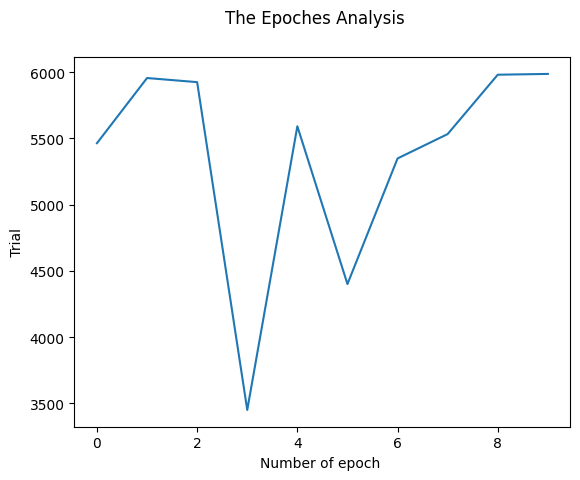

In [55]:
f, ax = plt.subplots(1)
ax.plot( all_epoches             )

ax.set_xlabel('Number of epoch ')
ax.set_ylabel(' Trial ')
f.suptitle("The Epoches Analysis")
plt.show(f)



## Use the Evaluated Epoches for the NN model 

In [88]:
epoches_opt=int(np.average(all_epoches))
epoches_opt=3000
epoches_opt

3000

In [89]:
import time
# Start timer
start_time = time.time()

from tensorflow import keras
from keras.layers import Dense , Input as Input_NN
from keras.callbacks import Callback


Traning_Error_all=[]
Test_Error_all=[]

physical_error_all=[]
data_error_all=[]



def loss(model, x, y):
      y_ = model(x)
      mse_data= tf.reduce_mean(tf.square( y_ - y))
      p_f=  x[:,2] +  x[:,3]*tf.tan(x[:,1])-9.81*tf.square(x[:,3])/( 2*tf.square(x[:,0])*tf.square(tf.cos(x[:,1])) )
      P_f=tf.reshape(p_f, (p_f.shape[0], 1))
      physics_loss = tf.reduce_mean(tf.square(y_ - P_f))
      physical_error.append(physics_loss )
      data_error.append(mse_data)
      return   physics_loss + mse_data

def grad(model, inputs, targets):
    with tf.GradientTape() as tape:
         loss_value = loss(model, inputs, targets)
    return loss_value, tape.gradient(loss_value, model.trainable_variables)
optimizer = tf.keras.optimizers.Adam()


############## MODEL #####################
models = keras.models
model = models.Sequential()
# input layer
model.add(Input_NN(shape=(4,))) 
# Hidden layer
model.add(Dense(8, activation='softplus') ) # 1
model.add(Dense(8, activation='softplus') ) # 2
# Output layer
model.add(Dense(1, activation='softplus') )
############# MODEL #####################

for epoch in range(epoches_opt):
    physical_error=[]
    data_error=[]
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
            x=x_batch_train
            y=y_batch_train
            epoch_loss_avg = tf.keras.metrics.Mean()
            epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
            
            # Training loop - using batches of 32
            # Optimize the model
            loss_value, grads = grad(model, x , y )
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            
            # Track progress
            epoch_loss_avg.update_state(loss_value)  # Add current batch loss
            epoch_accuracy.update_state(y, model(x))
    y_model_test=model(x_test)
    y_model_train=model(x_train)
    
    Traning_Error_all.append(tf.reduce_mean(tf.square(y_model_train - y_train)))
    Test_Error_all.append(tf.reduce_mean(tf.square(y_model_test - y_test)))
    physical_error_all.append(tf.reduce_mean(physical_error))
    data_error_all.append(tf.reduce_mean(data_error))

# End timer
end_time = time.time()
# Calculate elapsed time
elapsed_time = end_time - start_time
print("Elapsed time: ", elapsed_time)

Elapsed time:  845.0941257476807


### Error Analysis

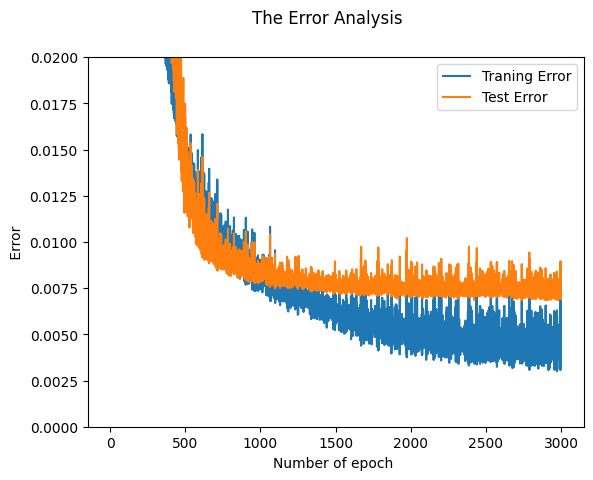

In [91]:
f, ax = plt.subplots(1)

ax.plot( Traning_Error_all               ,  label = 'Traning Error')
ax.plot(  Test_Error_all                ,  label = 'Test Error')
ax.set_ylim(0.0, 0.02)
ax.set_xlabel('Number of epoch ')
ax.set_ylabel(' Error ')
f.suptitle("The Error Analysis")
ax.legend()
plt.show(f)




## loss Analysis

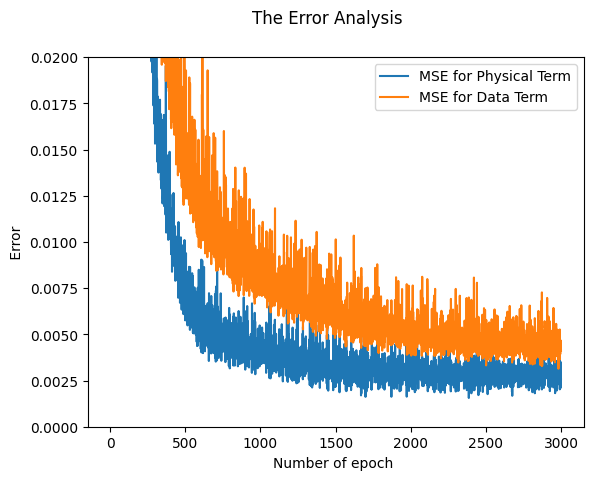

In [92]:
f, ax = plt.subplots(1)

ax.plot( physical_error_all               ,  label = 'MSE for Physical Term')
ax.plot( data_error_all                 ,  label = 'MSE for Data Term')
ax.set_ylim(0.0, 0.02)
ax.set_xlabel('Number of epoch ')
ax.set_ylabel(' Error ')
f.suptitle("The Error Analysis")
ax.legend()
plt.show(f)


## Test The Model on Test Data

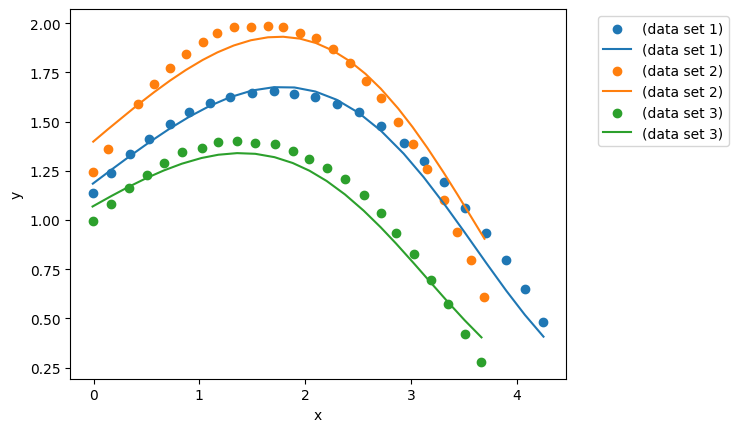

In [93]:
k=1
for i in unique_sets_Test :
     filtered_data_Test_Data_PINN = Test_Data_PINN[Test_Data_PINN['launching velocity'] == i]
     x=filtered_data_Test_Data_PINN[[' horizontal Distance ']]
     y=filtered_data_Test_Data_PINN[['vertical Distance']]
     y_predict= model.predict(filtered_data_Test_Data_PINN[Input],verbose=0)
     
     plt.scatter(x,y, label=f'(data set {k})')
     plt.plot(x,y_predict, label=f'(data set {k})')
     k+=1 
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Test The Model on Traning Data

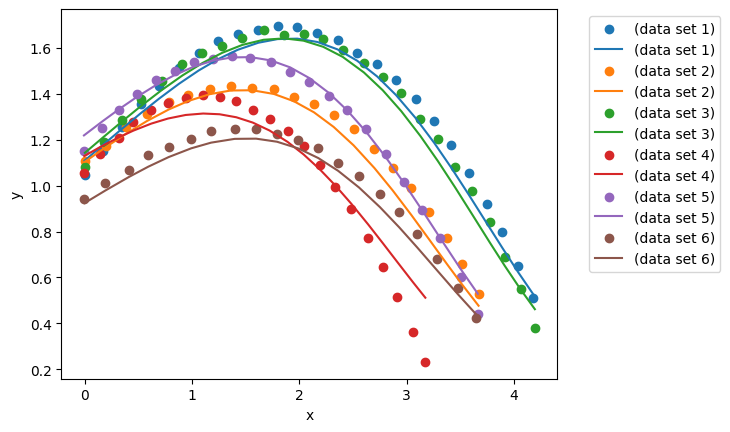

In [94]:
k=1
for i in unique_sets_Traning :
     filtered_Traning_Data_PINN = Traning_Data_PINN[Traning_Data_PINN['launching velocity'] == i]
     x=filtered_Traning_Data_PINN[[' horizontal Distance ']]
     y=filtered_Traning_Data_PINN[['vertical Distance']]
     y_predict= model.predict(filtered_Traning_Data_PINN[Input],verbose=0)
     
     plt.scatter(x,y, label=f'(data set {k})')
     plt.plot(x,y_predict, label=f'(data set {k})')
     k+=1 
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [95]:
#np.savetxt('Traning_Predection_NN .csv', model.predict(Traning_Data_PINN[Input],verbose=0) , delimiter=',')
#np.savetxt('Test_Prediction_NN .csv', model.predict(Test_Data_PINN[Input],verbose=0) , delimiter=',')

# Use Theoritical Physical Model

In [96]:


y_predection_Physical_Test= (
    Test_Data_PINN['initial height'] + 
    np.tan(Test_Data_PINN['launching angel'] ) *Test_Data_PINN[' horizontal Distance ']   
    - 9.81*Test_Data_PINN[' horizontal Distance ']**2 /(2*Test_Data_PINN['launching velocity']**2*np.cos(Test_Data_PINN['launching angel'] )**2 )

)
y_predection_Physical_Traning=(
    Traning_Data_PINN['initial height'] + 
    np.tan(Traning_Data_PINN['launching angel'] ) *Traning_Data_PINN[' horizontal Distance ']   
    - 9.81*Traning_Data_PINN[' horizontal Distance ']**2 /(2*Traning_Data_PINN['launching velocity']**2*np.cos(Traning_Data_PINN['launching angel'] )**2 )
)

In [97]:
#np.savetxt('Test_Prediction_Physical .csv', y_predection_Physical_Test , delimiter=',')
#np.savetxt('Traning_Prediction_Physical .csv', y_predection_Physical_Traning , delimiter=',')

## Test The Physical Model on Test Data

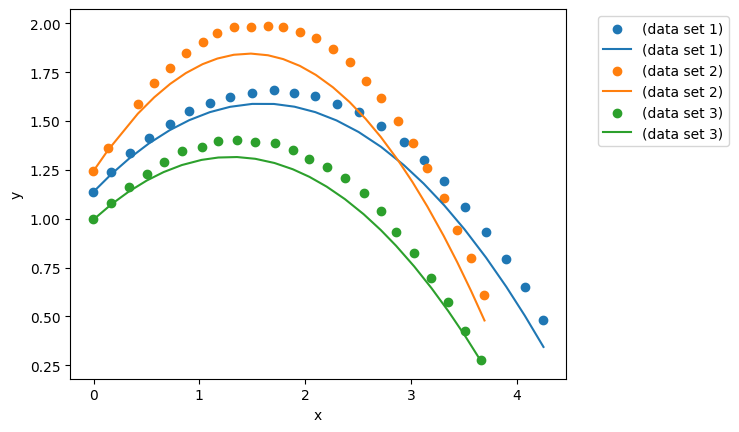

In [98]:
k=1
for i in unique_sets_Test :
     filtered_data_Test_Data_PINN = Test_Data_PINN[Test_Data_PINN['launching velocity'] == i]
     x=filtered_data_Test_Data_PINN[[' horizontal Distance ']]
     y=filtered_data_Test_Data_PINN[['vertical Distance']]
    
     y_predection_Physical_Test_filtered= (
         filtered_data_Test_Data_PINN['initial height'] + 
         np.tan(filtered_data_Test_Data_PINN['launching angel'] ) *filtered_data_Test_Data_PINN[' horizontal Distance ']   
         - 9.81*filtered_data_Test_Data_PINN[' horizontal Distance ']**2 /
         (2*filtered_data_Test_Data_PINN['launching velocity']**2*np.cos(filtered_data_Test_Data_PINN['launching angel'] )**2 )
     )
     plt.scatter(x,y, label=f'(data set {k})')
     plt.plot(x, y_predection_Physical_Test_filtered, label=f'(data set {k})')
     k+=1 
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Test The Physical Model on Train Data

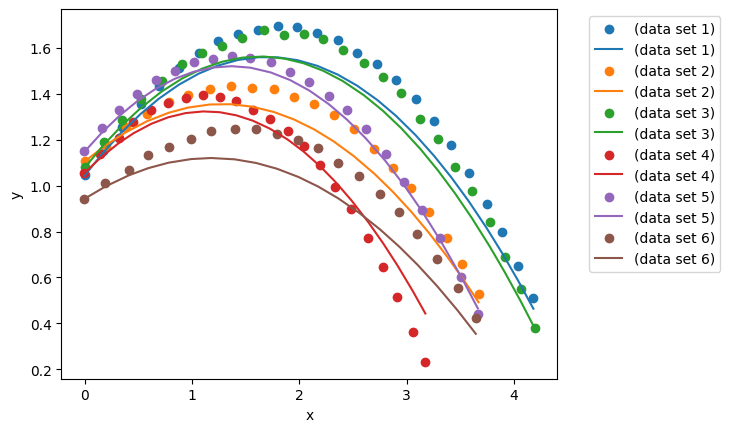

In [99]:
k=1
for i in unique_sets_Traning :
     filtered_Traning_Data_PINN = Traning_Data_PINN[Traning_Data_PINN['launching velocity'] == i]
     x=filtered_Traning_Data_PINN[' horizontal Distance ']
     y=filtered_Traning_Data_PINN['vertical Distance']
     y_predection_Physical_Train_filtered= (
         filtered_Traning_Data_PINN['initial height'] + 
         np.tan(filtered_Traning_Data_PINN['launching angel'] ) *filtered_Traning_Data_PINN[' horizontal Distance ']   
         - 9.81*filtered_Traning_Data_PINN[' horizontal Distance ']**2 /
         (2*filtered_Traning_Data_PINN['launching velocity']**2*np.cos(filtered_Traning_Data_PINN['launching angel'] )**2 )
     )
     
     plt.scatter(x,y, label=f'(data set {k})')
     plt.plot(x, y_predection_Physical_Train_filtered, label=f'(data set {k})')
     k+=1 
     
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Mean Square Error bewtween NN model and data vs Theoriticla Model and Data 

In [106]:



MSE_theoritiacal_Test= (
     ((np.reshape( y_predection_Physical_Test , (len(y_predection_Physical_Test ),1))-  model.predict(Test_Data_PINN[Input],verbose=0)) ** 2).sum()/len( y_predection_Physical_Test)
    
)
MSE_theoritiacal_Traning= (
     ((np.reshape( y_predection_Physical_Traning , (len(y_predection_Physical_Traning ),1))-  model.predict(Traning_Data_PINN[Input],verbose=0)) ** 2).sum()/len( y_predection_Physical_Traning)
    
)

MSE_NN_Traning = (
    ((  model.predict(Traning_Data_PINN[Input],verbose=0) - 
      np.reshape( Traning_Data_PINN['vertical Distance'], (len(Traning_Data_PINN),1)) ) ** 2).sum()/len(Traning_Data_PINN)
)

MSE_NN_Test = (
    ((  model.predict(Test_Data_PINN[Input],verbose=0) -  
      np.reshape(Test_Data_PINN['vertical Distance'], (len(Test_Data_PINN),1)) ) ** 2).sum()/len(Test_Data_PINN)       
)
MSE_PINN=MSE_NN_Traning + MSE_NN_Test 
MSE_theoritiacal=  MSE_theoritiacal_Traning  + MSE_theoritiacal_Test 

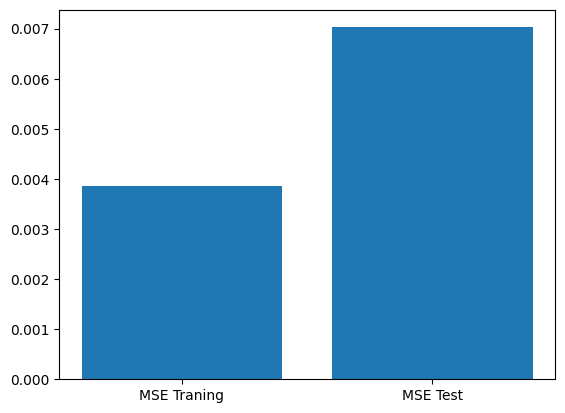

In [107]:

x_plot = ["MSE Traning", "MSE Test"]
y_plot = [MSE_NN_Traning, MSE_NN_Test]

plt.bar(x_plot, y_plot)
plt.show()

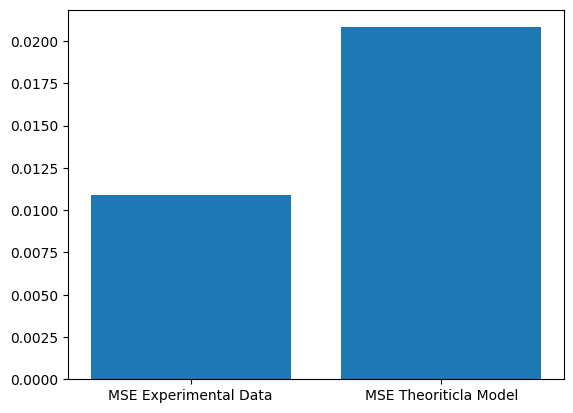

In [108]:
x_plot = ["MSE Experimental Data", "MSE Theoriticla Model"]
y_plot = [MSE_PINN , MSE_theoritiacal]

plt.bar(x_plot, y_plot)
plt.show()